In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pickle
import warnings
warnings.filterwarnings('ignore')
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [40]:
BASE_PATH   = "/kaggle/input/gtsrb-german-traffic-sign"
TRAIN_PATH  = os.path.join(BASE_PATH, "Train")
TEST_PATH   = os.path.join(BASE_PATH, "Test")
TEST_CSV    = os.path.join(BASE_PATH, "Test.csv")
META_CSV    = os.path.join(BASE_PATH, "Meta.csv")        # class metadata
 
# Output paths (writable in Kaggle)
WORKING_DIR   = "/kaggle/working/"
PROCESSED_DIR = os.path.join(WORKING_DIR, "processed")
OUTPUTS_DIR   = os.path.join(WORKING_DIR, "outputs")
 
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [41]:
IMG_SIZE    = (64, 64)
NUM_CLASSES = 43
BATCH_SIZE  = 32
RANDOM_SEED = 42

In [145]:
CLASS_LABELS = {
    0:  "Speed limit (20km/h)",        1:  "Speed limit (30km/h)",
    2:  "Speed limit (50km/h)",        3:  "Speed limit (60km/h)",
    4:  "Speed limit (70km/h)",        5:  "Speed limit (80km/h)",
    6:  "End of speed limit (80km/h)", 7:  "Speed limit (100km/h)",
    8:  "Speed limit (120km/h)",       9:  "No passing",
    10: "No passing (vehicles >3.5t)", 11: "Right-of-way at intersection",
    12: "Priority road",               13: "Yield",
    14: "Stop",                        15: "No vehicles",
    16: "Vehicles >3.5t prohibited",   17: "No entry",
    18: "General caution",             19: "Dangerous curve left",
    20: "Dangerous curve right",       21: "Double curve",
    22: "Bumpy road",                  23: "Slippery road",
    24: "Road narrows on right",       25: "Road work",
    26: "Traffic signals",             27: "Pedestrians",
    28: "Children crossing",           29: "Bicycles crossing",
    30: "Beware of ice/snow",          31: "Wild animals crossing",
    32: "End of all limits",           33: "Turn right ahead",
    34: "Turn left ahead",             35: "Ahead only",
    36: "Go straight or right",        37: "Go straight or left",
    38: "Keep right",                  39: "Keep left",
    40: "Roundabout mandatory",        41: "End of no passing",
    42: "End of no passing (>3.5t)",
}
 
DRIVER_MESSAGES = {
    0:  " Reduce speed to 20 km/h",
    1:  " Reduce speed to 30 km/h",
    2:  " Reduce speed to 50 km/h",
    3:  " Reduce speed to 60 km/h",
    4:  " Reduce speed to 70 km/h",
    5:  " Reduce speed to 80 km/h",
    6:  " Speed limit lifted — drive safely",
    7:  " Speed limit: 100 km/h",
    8:  " Speed limit: 120 km/h",
    9:  " No overtaking allowed",
    10: " No overtaking for heavy vehicles",
    11: " You have right of way at next intersection",
    12: " You are on a priority road",
    13: " Yield to oncoming traffic",
    14: " Stop! Come to a complete stop",
    15: " No vehicles allowed on this road",
    16: " Heavy vehicles prohibited",
    17: " No entry — wrong direction!",
    18: " General caution ahead",
    19: " Dangerous left curve — slow down",
    20: " Dangerous right curve — slow down",
    21: " Double curve ahead — reduce speed",
    22: " Bumpy road — slow down",
    23: " Slippery road — drive carefully",
    24: " Road narrows — keep right",
    25: " Road work ahead — slow down",
    26: " Traffic signals ahead",
    27: " Pedestrians ahead — slow down",
    28: " Children crossing — slow down!",
    29: " Cyclists crossing ahead",
    30: " Ice/snow on road — drive carefully",
    31: " Wild animals may cross — slow down",
    32: " All restrictions lifted",
    33: " Turn right ahead",
    34: " Turn left ahead",
    35: " Go straight ahead",
    36: " Go straight or turn right",
    37: " Go straight or turn left",
    38: " Keep to the right",
    39: " Keep to the left",
    40: " Roundabout ahead — reduce speed",
    41: " Overtaking restriction lifted",
    42: " Heavy vehicle overtaking restriction lifted",
}
 

In [21]:
def verify_dataset():
    print("=" * 55)
    print("  GTSRB Dataset Verification")
    print("=" * 55)
 
    assert os.path.exists(BASE_PATH), (
        f"❌ Dataset not found at {BASE_PATH}\n"
        "   → In Kaggle: Add Data → Search 'GTSRB German Traffic Sign'"
    )
 
    # Check class folders
    class_folders = [f for f in os.listdir(TRAIN_PATH)
                     if os.path.isdir(os.path.join(TRAIN_PATH, f))]
    print(f"✅ Dataset found at: {BASE_PATH}")
    print(f"✅ Training class folders: {len(class_folders)}")
    print(f"✅ Test CSV exists: {os.path.exists(TEST_CSV)}")
 
    # Count total images
    total_train = sum(
        len(os.listdir(os.path.join(TRAIN_PATH, c)))
        for c in class_folders
    )
    test_df = pd.read_csv(TEST_CSV)
    print(f"✅ Total train images : ~{total_train}")
    print(f"✅ Total test images  : {len(test_df)}")
    print()
    return test_df
 

In [22]:
def load_train_data(img_size=IMG_SIZE):
    """Load all training images from class subfolders."""
    images, labels = [], []
 
    print("📂 Loading training images...")
    for class_id in range(NUM_CLASSES):
        class_path = os.path.join(TRAIN_PATH, str(class_id))
        count = 0
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith((".png", ".jpg", ".ppm", ".jpeg")):
                try:
                    img = Image.open(os.path.join(class_path, img_file))
                    img = img.convert("RGB").resize(img_size)
                    images.append(np.array(img))
                    labels.append(class_id)
                    count += 1
                except Exception:
                    pass
        if class_id % 10 == 0:
            print(f"  Progress: class {class_id}/{NUM_CLASSES-1} ...")
 
    images = np.array(images, dtype=np.uint8)
    labels = np.array(labels)
    print(f"✅ Train loaded: {images.shape}  Labels: {labels.shape}")
    return images, labels
 
 
def load_test_data(img_size=IMG_SIZE):
    """Load test images using Test.csv."""
    df = pd.read_csv(TEST_CSV)
    images, labels = [], []
 
    print("📂 Loading test images...")
    for _, row in df.iterrows():
        img_path = os.path.join(BASE_PATH, row["Path"])
        try:
            img = Image.open(img_path).convert("RGB").resize(img_size)
            images.append(np.array(img))
            labels.append(row["ClassId"])
        except Exception:
            pass
 
    images = np.array(images, dtype=np.uint8)
    labels = np.array(labels)
    print(f"✅ Test loaded: {images.shape}  Labels: {labels.shape}")
    return images, labels

In [23]:
def apply_clahe(img_rgb):
    """
    CLAHE (Contrast Limited Adaptive Histogram Equalization)
    Helps with dark tunnels, bright sunlight, rain — real driving conditions.
    """
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
 
 
def preprocess_images(images, use_clahe=True):
    """Normalize to [0,1] with optional CLAHE enhancement."""
    processed = []
    for img in images:
        if use_clahe:
            img = apply_clahe(img)
        processed.append(img.astype(np.float32) / 255.0)
    return np.array(processed)
 
 
def encode_labels(labels):
    return to_categorical(labels, num_classes=NUM_CLASSES)
 
 
def compute_class_weights(labels):
    weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels),
        y=labels
    )
    return dict(enumerate(weights))

In [24]:
def get_augmented_generator(X_train, y_train, batch_size=BATCH_SIZE):
    """
    Augmentation tuned for traffic signs:
    - No horizontal flip (signs are NOT symmetric)
    - Brightness variation (day/night/overcast)
    - Slight rotation & zoom (camera angle variation)
    """
    datagen = ImageDataGenerator(
        rotation_range=12,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        brightness_range=[0.6, 1.4],
        horizontal_flip=False,
        fill_mode='nearest'
    )
    return datagen.flow(X_train, y_train, batch_size=batch_size, seed=RANDOM_SEED)

In [25]:
def plot_class_distribution(labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    fig, ax = plt.subplots(figsize=(18, 5))
    colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
    bars = ax.bar(range(NUM_CLASSES), counts, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel("Class ID", fontsize=12)
    ax.set_ylabel("Image Count", fontsize=12)
    ax.set_title("GTSRB Class Distribution (Training Set)", fontsize=14, fontweight='bold')
    ax.set_xticks(range(NUM_CLASSES))
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.grid(axis='y', alpha=0.3)
 
    # Annotate min and max
    ax.annotate(f"Max: {counts.max()}", xy=(counts.argmax(), counts.max()),
                xytext=(counts.argmax()+2, counts.max()-300),
                arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
    ax.annotate(f"Min: {counts.min()}", xy=(counts.argmin(), counts.min()),
                xytext=(counts.argmin()+2, counts.min()+300),
                arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)
 
    plt.tight_layout()
    path = os.path.join(OUTPUTS_DIR, "class_distribution.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"💾 Saved: {path}")
    print(f"   Most frequent class: {counts.argmax()} ({CLASS_LABELS[counts.argmax()]}) — {counts.max()} images")
    print(f"   Least frequent class: {counts.argmin()} ({CLASS_LABELS[counts.argmin()]}) — {counts.min()} images")
    print(f"   Imbalance ratio: {counts.max() / counts.min():.1f}x")
 
 
def plot_sample_grid(images, labels, n_classes=10, n_per_class=5):
    """Show raw vs CLAHE-enhanced images side by side."""
    fig, axes = plt.subplots(n_classes, n_per_class * 2,
                             figsize=(n_per_class * 4, n_classes * 2.2))
    fig.suptitle("Raw  |  CLAHE Enhanced  (first 10 classes)", fontsize=13, fontweight='bold')
 
    raw_images_uint8 = (images * 255).astype(np.uint8)  # already preprocessed
 
    for row, class_id in enumerate(range(n_classes)):
        class_idx = np.where(labels == class_id)[0]
        samples = class_idx[:n_per_class]
 
        for col, idx in enumerate(samples):
            # Raw
            ax_raw = axes[row][col]
            ax_raw.imshow(raw_images_uint8[idx])
            ax_raw.axis('off')
            if col == 0:
                ax_raw.set_ylabel(f"C{class_id}", fontsize=7, rotation=0, labelpad=20)
 
            # CLAHE enhanced
            ax_enh = axes[row][col + n_per_class]
            enhanced = apply_clahe(raw_images_uint8[idx])
            ax_enh.imshow(enhanced)
            ax_enh.axis('off')
 
    plt.tight_layout()
    path = os.path.join(OUTPUTS_DIR, "sample_grid.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"💾 Saved: {path}")
 
 
def plot_driver_messages_preview(n=8):
    """Preview class → driver message mapping."""
    print("\n Driver Message Preview:")
    print("-" * 55)
    for class_id in range(n):
        print(f"  Class {class_id:2d} | {CLASS_LABELS[class_id]:<30} → {DRIVER_MESSAGES[class_id]}")
    print("  ...")
    print("-" * 55)
 

In [27]:
def save_all(X_train, X_val, X_test, y_train, y_val, y_test, raw_train_labels):
    np.save(f"{PROCESSED_DIR}/X_train.npy", X_train)
    np.save(f"{PROCESSED_DIR}/X_val.npy",   X_val)
    np.save(f"{PROCESSED_DIR}/X_test.npy",  X_test)
    np.save(f"{PROCESSED_DIR}/y_train.npy", y_train)
    np.save(f"{PROCESSED_DIR}/y_val.npy",   y_val)
    np.save(f"{PROCESSED_DIR}/y_test.npy",  y_test)
 
    cw = compute_class_weights(raw_train_labels)
    with open(f"{PROCESSED_DIR}/class_weights.pkl", "wb") as f:
        pickle.dump(cw, f)
 
    # Also save label maps for live detection phase
    import json
    with open(f"{PROCESSED_DIR}/class_labels.json", "w") as f:
        json.dump(CLASS_LABELS, f)
    with open(f"{PROCESSED_DIR}/driver_messages.json", "w") as f:
        json.dump(DRIVER_MESSAGES, f)
 
    print(f"\n💾 All data saved to {PROCESSED_DIR}/")
    print(f"   Files: X_train, X_val, X_test, y_train, y_val, y_test")
    print(f"          class_weights.pkl, class_labels.json, driver_messages.json")

In [28]:
def run_preprocessing_pipeline():
    print("=" * 55)
    print("  TRAFFIC SIGN — DATA PREPROCESSING (Kaggle)")
    print("=" * 55)
 
    # 1. Verify
    verify_dataset()
 
    # 2. Load raw images
    X_raw_train, y_raw_train = load_train_data()
    X_raw_test,  y_raw_test  = load_test_data()
 
    # 3. Preprocess (CLAHE + normalize)
    print("\n🔧 Applying CLAHE + normalization...")
    X_train_proc = preprocess_images(X_raw_train, use_clahe=True)
    X_test_proc  = preprocess_images(X_raw_test,  use_clahe=True)
    print(f"   Train: {X_train_proc.shape}  dtype: {X_train_proc.dtype}")
    print(f"   Test : {X_test_proc.shape}   dtype: {X_test_proc.dtype}")
 
    # 4. Train / Val split (stratified)
    X_train, X_val, y_train_raw, y_val_raw = train_test_split(
        X_train_proc, y_raw_train,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y_raw_train
    )
    print(f"\n📊 Split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test_proc)}")
 
    # 5. One-hot encode
    y_train = encode_labels(y_train_raw)
    y_val   = encode_labels(y_val_raw)
    y_test  = encode_labels(y_raw_test)
 
    # 6. Visualize
    plot_class_distribution(y_raw_train)
    plot_sample_grid(X_train_proc, y_raw_train)
    plot_driver_messages_preview()
 
    # 7. Save
    save_all(X_train, X_val, X_test_proc, y_train, y_val, y_test, y_train_raw)
 
    print("\n✅ Preprocessing complete!")
    print(f"   Model input shape  : {X_train.shape[1:]}")
    print(f"   Number of classes  : {NUM_CLASSES}")
    print(f"   Ready for Phase 2  : Model Training")
 
    return X_train, X_val, X_test_proc, y_train, y_val, y_test

  TRAFFIC SIGN — DATA PREPROCESSING (Kaggle)
  GTSRB Dataset Verification
✅ Dataset found at: /kaggle/input/gtsrb-german-traffic-sign
✅ Training class folders: 43
✅ Test CSV exists: True
✅ Total train images : ~39209
✅ Total test images  : 12630

📂 Loading training images...
  Progress: class 0/42 ...
  Progress: class 10/42 ...
  Progress: class 20/42 ...
  Progress: class 30/42 ...
  Progress: class 40/42 ...
✅ Train loaded: (39209, 64, 64, 3)  Labels: (39209,)
📂 Loading test images...
✅ Test loaded: (12630, 64, 64, 3)  Labels: (12630,)

🔧 Applying CLAHE + normalization...
   Train: (39209, 64, 64, 3)  dtype: float32
   Test : (12630, 64, 64, 3)   dtype: float32

📊 Split → Train: 31367 | Val: 7842 | Test: 12630


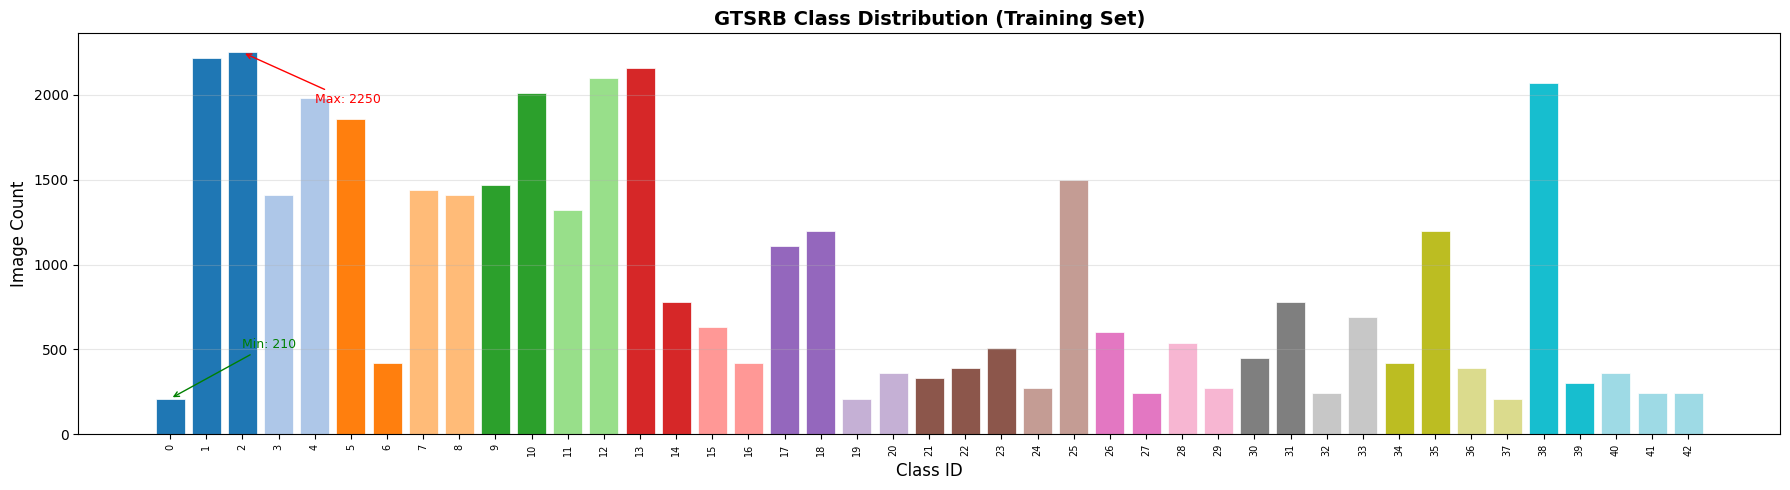

💾 Saved: /kaggle/working/outputs/class_distribution.png
   Most frequent class: 2 (Speed limit (50km/h)) — 2250 images
   Least frequent class: 0 (Speed limit (20km/h)) — 210 images
   Imbalance ratio: 10.7x


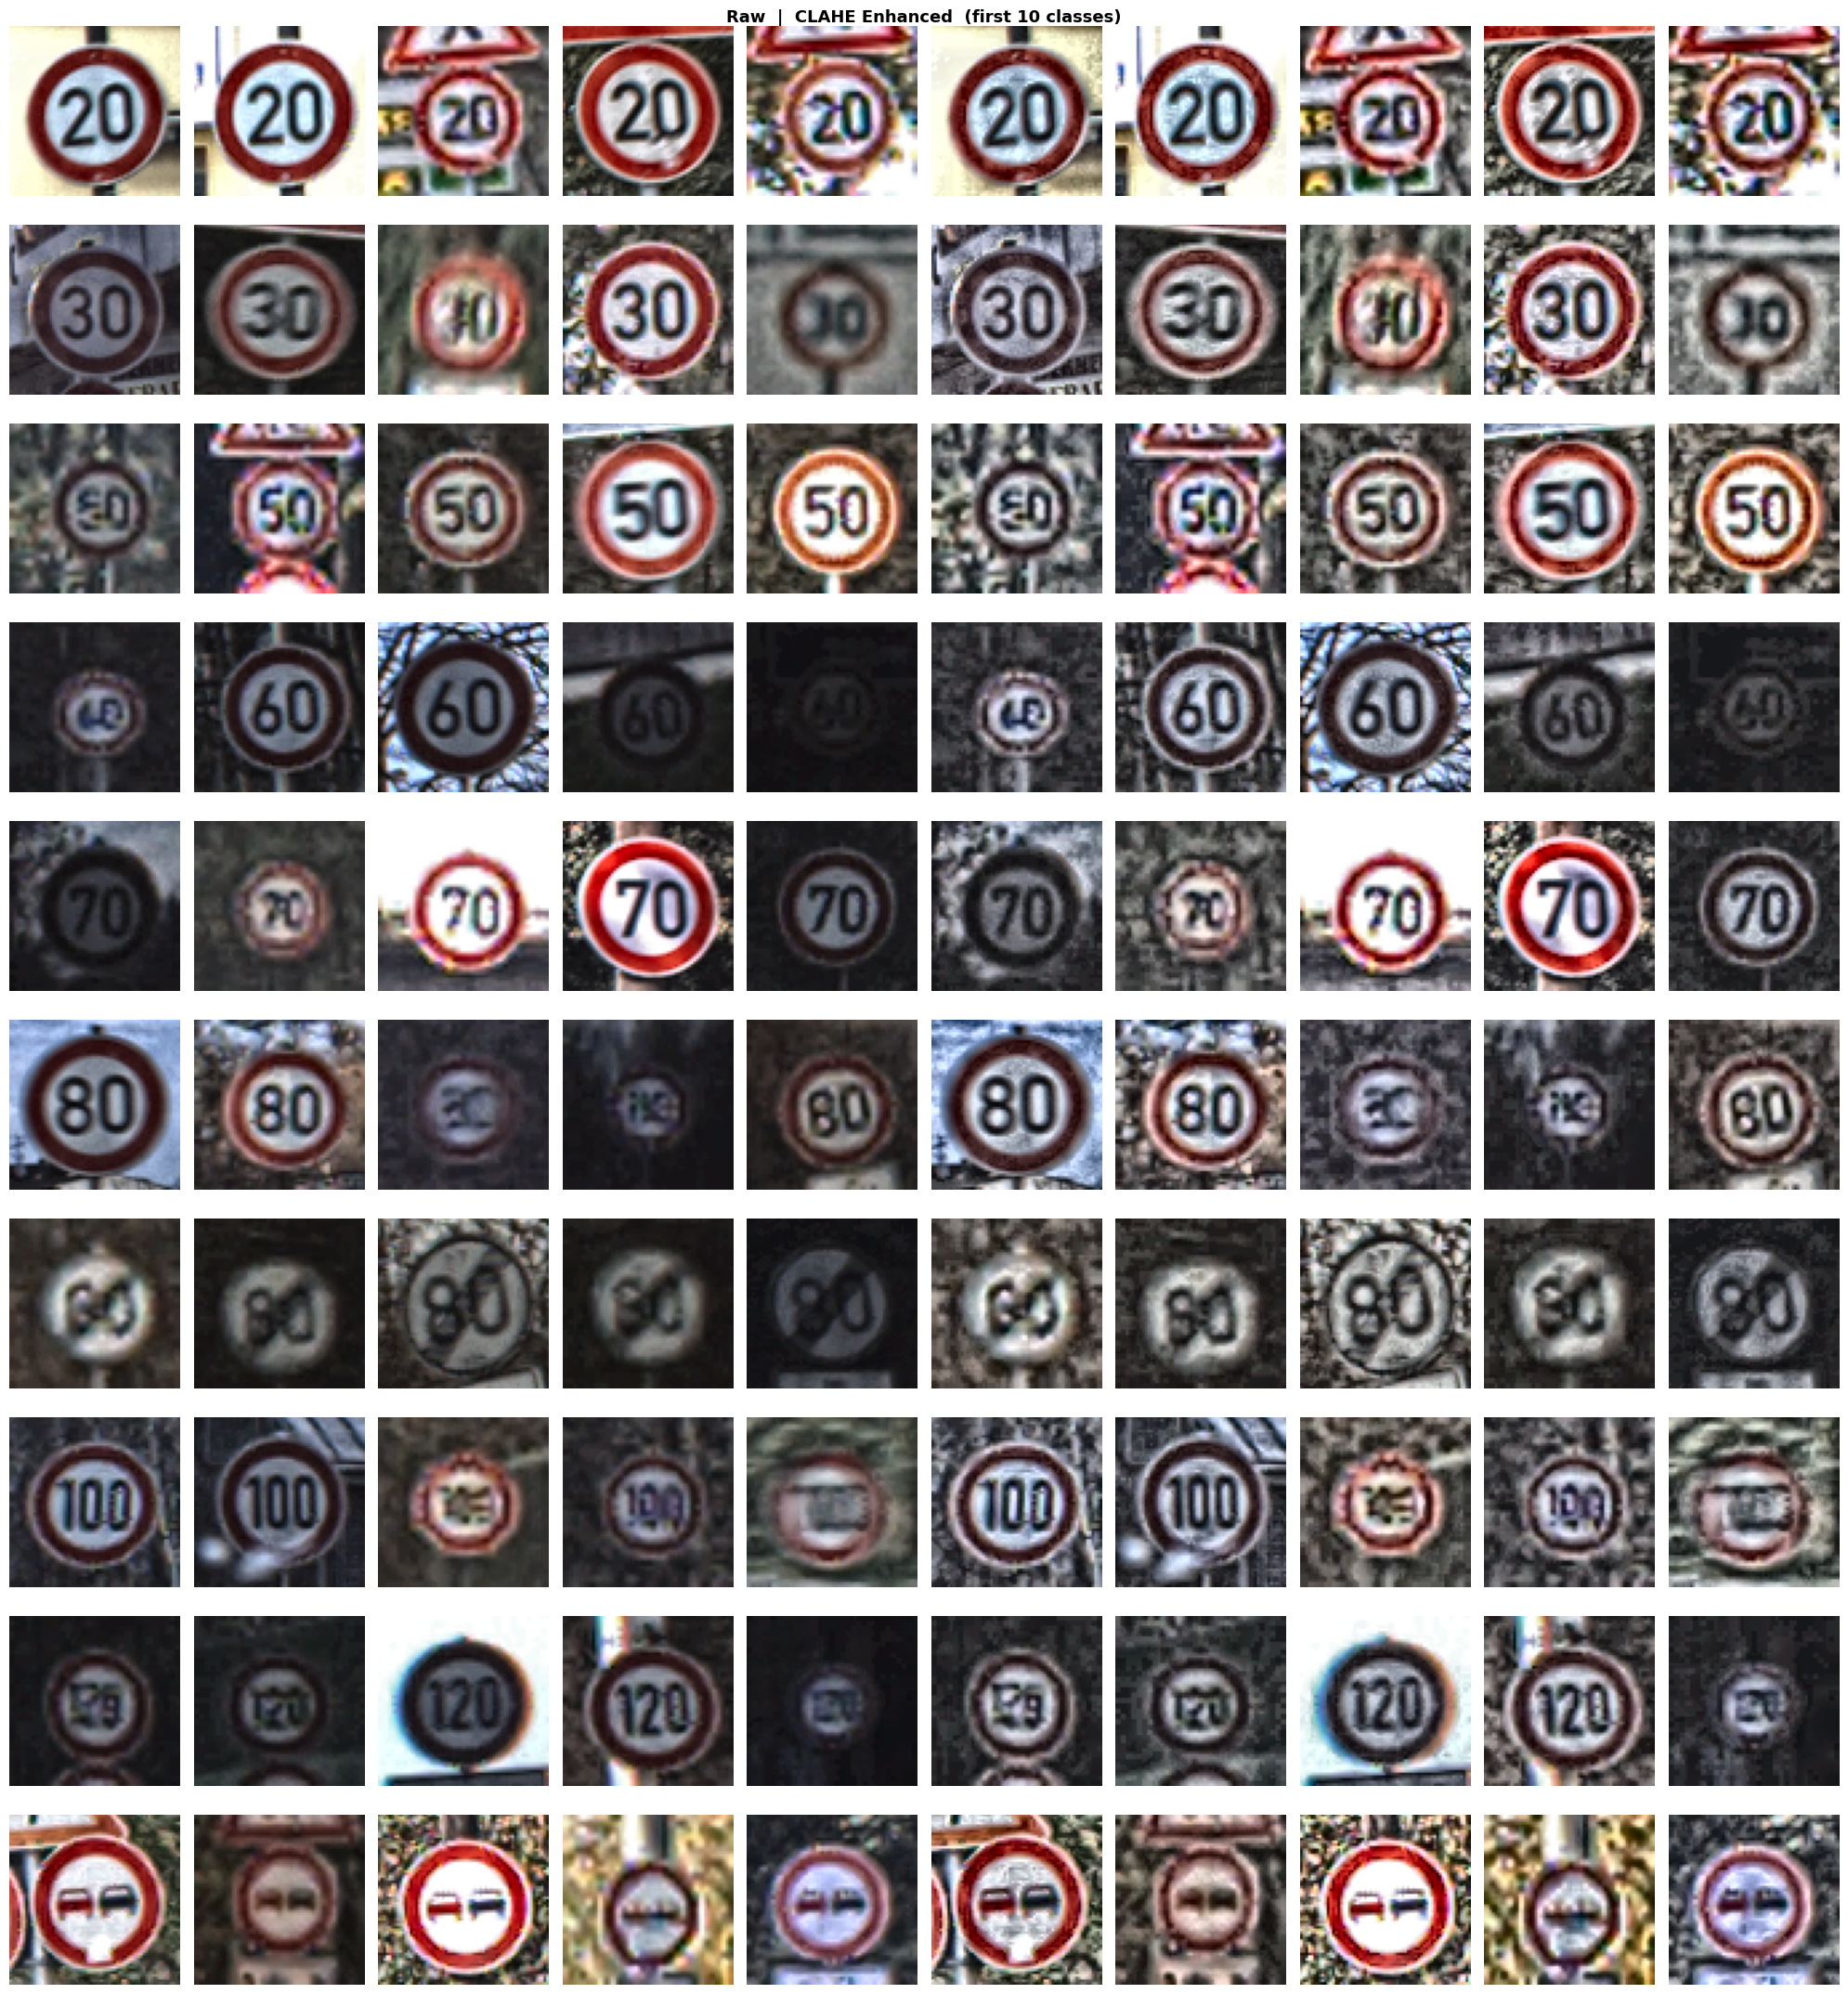

💾 Saved: /kaggle/working/outputs/sample_grid.png

🚗  Driver Message Preview:
-------------------------------------------------------
  Class  0 | Speed limit (20km/h)           → ⚠️  Reduce speed to 20 km/h
  Class  1 | Speed limit (30km/h)           → ⚠️  Reduce speed to 30 km/h
  Class  2 | Speed limit (50km/h)           → ⚠️  Reduce speed to 50 km/h
  Class  3 | Speed limit (60km/h)           → ⚠️  Reduce speed to 60 km/h
  Class  4 | Speed limit (70km/h)           → ⚠️  Reduce speed to 70 km/h
  Class  5 | Speed limit (80km/h)           → ⚠️  Reduce speed to 80 km/h
  Class  6 | End of speed limit (80km/h)    → ✅  Speed limit lifted — drive safely
  Class  7 | Speed limit (100km/h)          → ⚠️  Speed limit: 100 km/h
  ...
-------------------------------------------------------

💾 All data saved to /kaggle/working/processed/
   Files: X_train, X_val, X_test, y_train, y_val, y_test
          class_weights.pkl, class_labels.json, driver_messages.json

✅ Preprocessing complete!
   Mo

In [44]:
X_train, X_val, X_test, y_train, y_val, y_test = run_preprocessing_pipeline()

In [45]:
# Phase 2  - Model Training

In [46]:
import os, json, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
warnings.filterwarnings('ignore')

In [64]:
 
INPUT_SHAPE   = (64, 64, 3)
NUM_CLASSES   = 43
BATCH_SIZE    = 32
EPOCHS        = 30
RANDOM_SEED   = 42
 
PROCESSED_DIR = "/kaggle/working/processed"
MODELS_DIR    = "/kaggle/working/models"
OUTPUTS_DIR   = "/kaggle/working/outputs"
LOG_DIR       = "/kaggle/working/logs"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
def load_data():
    X_train = np.load(f"{PROCESSED_DIR}/X_train.npy")
    X_val   = np.load(f"{PROCESSED_DIR}/X_val.npy")
    X_test  = np.load(f"{PROCESSED_DIR}/X_test.npy")
    y_train = np.load(f"{PROCESSED_DIR}/y_train.npy")
    y_val   = np.load(f"{PROCESSED_DIR}/y_val.npy")
    y_test  = np.load(f"{PROCESSED_DIR}/y_test.npy")
    with open(f"{PROCESSED_DIR}/class_weights.pkl", "rb") as f:
        class_weights = pickle.load(f)
    with open(f"{PROCESSED_DIR}/class_labels.json") as f:
        class_labels = json.load(f)
 
    print(f" Data loaded:")
    print(f"   Train : {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    return X_train, X_val, X_test, y_train, y_val, y_test, class_weights, class_labels

In [133]:
# Custom Layers of CNN

def build_custom_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=INPUT_SHAPE),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
 
        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
 
        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
 
        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="Custom_CNN")
    return model

In [67]:
# VGG 16

def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    for layer in base.layers:        layer.trainable = False
    for layer in base.layers[-4:]:   layer.trainable = True   # fine-tune last 4
 
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="VGG16_Transfer")
    return model

In [ ]:
# Resnet 50

def build_resnet50():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    for layer in base.layers:
        layer.trainable = False

    for layer in base.layers[-5:]:
        layer.trainable = True

    # Build model
    inp = tf.keras.Input(shape=INPUT_SHAPE)

    # IMPORTANT: training=True for fine-tuning
    x = base(inp, training=True)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)   # smaller = more stable
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # optional extra layer (light)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(inp, out, name="ResNet50_Transfer")

    return model


In [69]:
# Mobilenetv2

def build_mobilenetv2():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    for layer in base.layers:        layer.trainable = False
    for layer in base.layers[-30:]:  layer.trainable = True   # fine-tune last 30
 
    inp = tf.keras.Input(shape=INPUT_SHAPE)
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return tf.keras.Model(inp, out, name="MobileNetV2_Transfer")

In [90]:
def get_model(name):
    if name == "Custom_CNN":
        return build_custom_cnn(), 1e-3

    elif name == "MobileNetV2_Transfer":
        return build_mobilenetv2(), 1e-4

    elif name == "ResNet50_Transfer":
        return build_resnet50(), 1e-4

    elif name == "VGG16_Transfer":
        return build_vgg16(), 1e-4

    else:
        raise ValueError(f"Unknown model name: {name}")

In [71]:
def compile_model(model, lr):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')
        ]
    )
    return model

In [72]:
def get_callbacks(model_name):
    ckpt = os.path.join(MODELS_DIR, f"{model_name}_best.keras")
    return [
        callbacks.ModelCheckpoint(ckpt, monitor='val_accuracy',
                                  save_best_only=True, verbose=0),
        callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1),
    ]
 

In [84]:
def train(model, name, X_train, y_train, X_val, y_val, class_weights):

    print("\nTraining:", name)

    tf.keras.backend.clear_session()

    start = time.time()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=get_callbacks(name),
        verbose=1
    )

    return history, time.time() - start


In [74]:
def evaluate(model, name, X_test, y_test):

    preds = model.predict(X_test)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = np.mean(y_pred == y_true)

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        "model": name,
        "accuracy": round(acc * 100, 2),
        "macro_f1": round(report["macro avg"]["f1-score"], 4)
    }

    return result, y_true, y_pred


In [77]:
results_list = []

def save_results(results):
    df = pd.DataFrame(results_list)
    df.to_csv(f"{OUTPUTS_DIR}/results.csv", index=False)

    with open(f"{OUTPUTS_DIR}/results.json", "w") as f:
        json.dump(results_list, f, indent=2)

    print("\nSaved results to CSV + JSON")


In [80]:
def run_one_model(name):

    X_train, X_val, X_test, y_train, y_val, y_test, class_weights, class_labels = load_data()

    model, lr = get_model(name)
    model = compile_model(model, lr)

    history, train_time = train(
        model, name,
        X_train, y_train,
        X_val, y_val,
        class_weights
    )

    result, y_true, y_pred = evaluate(model, name, X_test, y_test)
    result["train_min"] = round(train_time / 30, 2)

    results_list.append(result)
    save_results(results_list)

    print(result)

    return model, history, y_true, y_pred


In [85]:
model, history, y_true, y_pred = run_one_model("Custom_CNN")


✅ Data loaded:
   Train : (31367, 64, 64, 3) | Val: (7842, 64, 64, 3) | Test: (12630, 64, 64, 3)

Training: Custom_CNN
Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.4210 - loss: 2.2550 - top3_acc: 0.5792 - val_accuracy: 0.9651 - val_loss: 0.1206 - val_top3_acc: 0.9929 - learning_rate: 0.0010
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9391 - loss: 0.1721 - top3_acc: 0.9904 - val_accuracy: 0.9668 - val_loss: 0.1087 - val_top3_acc: 0.9952 - learning_rate: 0.0010
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9599 - loss: 0.1101 - top3_acc: 0.9939 - val_accuracy: 0.9885 - val_loss: 0.0382 - val_top3_acc: 0.9985 - learning_rate: 0.0010
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9697 - loss: 0.0874 - top3_acc: 0.9954 - val_accuracy: 0.9888 - val_loss: 0.0389 - val_top3_acc: 0.9978 - learning_rate: 0.0010
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9744 - loss: 0.0799 - top3_ac

In [91]:
model, history, y_true, y_pred = run_one_model("VGG16_Transfer")

✅ Data loaded:
   Train : (31367, 64, 64, 3) | Val: (7842, 64, 64, 3) | Test: (12630, 64, 64, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training: VGG16_Transfer
Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 58s 52ms/step - accuracy: 0.3062 - loss: 2.6752 - top3_acc: 0.4998 - val_accuracy: 0.8041 - val_loss: 0.6196 - val_top3_acc: 0.9461 - learning_rate: 1.0000e-04
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.8060 - loss: 0.5325 - top3_acc: 0.9518 - val_accuracy: 0.9280 - val_loss: 0.2311 - val_top3_acc: 0.9884 - learning_rate: 1.0000e-04
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.9240 - loss: 0.1846 - top3_acc: 0.9878 - val_accuracy: 0.9389 - val_loss: 0.1909 - val_top3_acc: 0.9913 - learning_rate: 1.0000e-04
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.9642 - loss: 0.0843 - top3_acc: 0.9965 - val_accuracy: 0.9463 - val_loss: 0.1724 - val_top3_acc: 0.9939 - learning_rate: 1.0000e-04
Epoch 5/10
981/981 ━━━━━━━

In [96]:
model, history, y_true, y_pred = run_one_model("ResNet50_Transfer")

✅ Data loaded:
   Train : (31367, 64, 64, 3) | Val: (7842, 64, 64, 3) | Test: (12630, 64, 64, 3)

Training: ResNet50_Transfer
Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.1194 - loss: 3.5486 - top3_acc: 0.2433 - val_accuracy: 0.4030 - val_loss: 2.2294 - val_top3_acc: 0.6401 - learning_rate: 1.0000e-04
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.3518 - loss: 2.1967 - top3_acc: 0.5865 - val_accuracy: 0.4643 - val_loss: 1.7582 - val_top3_acc: 0.7153 - learning_rate: 1.0000e-04
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.4534 - loss: 1.7195 - top3_acc: 0.7038 - val_accuracy: 0.5598 - val_loss: 1.5091 - val_top3_acc: 0.7766 - learning_rate: 1.0000e-04
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.5230 - loss: 1.4141 - top3_acc: 0.7609 - val_accuracy: 0.5726 - val_loss: 1.4050 - val_top3_acc: 0.7964 - learning_rate: 1.0000e-04
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.5643 -

In [94]:
model, history, y_true, y_pred = run_one_model("MobileNetV2_Transfer")

✅ Data loaded:
   Train : (31367, 64, 64, 3) | Val: (7842, 64, 64, 3) | Test: (12630, 64, 64, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training: MobileNetV2_Transfer
Epoch 1/10


E0000 00:00:1777122790.329998     328 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777122790.465267     328 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


979/981 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2253 - loss: 3.2406 - top3_acc: 0.3797

E0000 00:00:1777122806.027275     328 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777122806.161712     328 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.2257 - loss: 3.2380 - top3_acc: 0.3803 - val_accuracy: 0.5987 - val_loss: 1.2954 - val_top3_acc: 0.8171 - learning_rate: 1.0000e-04
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6225 - loss: 1.1063 - top3_acc: 0.8393 - val_accuracy: 0.7735 - val_loss: 0.6937 - val_top3_acc: 0.9389 - learning_rate: 1.0000e-04
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7820 - loss: 0.5586 - top3_acc: 0.9346 - val_accuracy: 0.8461 - val_loss: 0.4816 - val_top3_acc: 0.9651 - learning_rate: 1.0000e-04
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8652 - loss: 0.3202 - top3_acc: 0.9694 - val_accuracy: 0.8647 - val_loss: 0.4141 - val_top3_acc: 0.9723 - learning_rate: 1.0000e-04
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9218 - loss: 0.1785 - top3_acc: 0.9864 - val_accuracy: 0.8957 - val_loss: 0.3238 - val_top3_acc: 0.9824 - learning_rate: 1.0000e-04
Epoch 6/10


In [165]:
# Evaluation

In [120]:
results = [
    {"model": "Custom CNN",         "Accuracy": 97.61, "f1": 0.9618, "train_min": 6.13},
    {"model": "VGG16 Transfer",     "Accuracy": 87.66, "f1": 0.8487, "train_min": 15.07},
    {"model": "ResNet50 Transfer",  "Accuracy": 66.31, "f1": 0.6238, "train_min": 8.2},
    {"model": "MobileNetV2",        "Accuracy": 71.65, "f1": 0.6233, "train_min": 4.64},
]

df = pd.DataFrame(results)
print(df.sort_values(by="Accuracy", ascending=False))


               model  Accuracy      f1  train_min
0         Custom CNN     97.61  0.9618       6.13
1     VGG16 Transfer     87.66  0.8487      15.07
3        MobileNetV2     71.65  0.6233       4.64
2  ResNet50 Transfer     66.31  0.6238       8.20


In [121]:
best_model = df.loc[df["Accuracy"].idxmax()]
print("Best Model:\n", best_model)

Best Model:
 model        Custom CNN
Accuracy          97.61
f1               0.9618
train_min          6.13
Name: 0, dtype: object


In [140]:
model.save("best_cnn_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


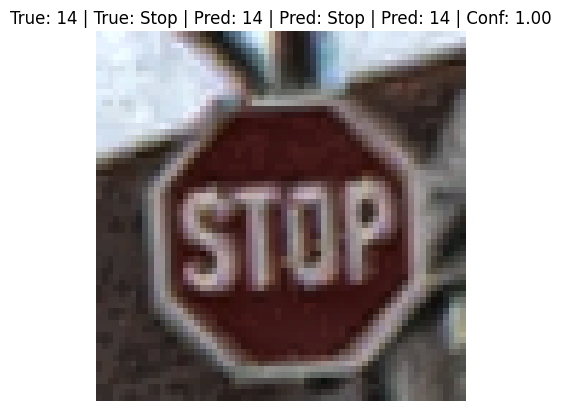

In [164]:
idx = np.random.randint(0, len(X_test))

img = X_test[idx]
true_label = np.argmax(y_test[idx])

img_input = np.expand_dims(img, axis=0)

pred = model.predict(img_input)
pred_label = np.argmax(pred)
confidence = np.max(pred)

plt.imshow(img)
plt.title(
    f"True: {true_label} | " 
    f"True: {CLASS_LABELS[true_label]} | "
    f"Pred: {pred_label} | "
    f"Pred: {CLASS_LABELS[pred_label]} | "
    f"Pred: {pred_label} | "
    f"Conf: {confidence:.2f}" 
)
plt.axis("off")
plt.show()
